In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import json
import pathlib
from scipy.signal import welch, find_peaks
from src.models.dual_rotor_beam_drone import DualRotorBeamDrone
from src.models.base import State
from src.controllers.pid import PIDController
from src.sensors.angle_sensor import AngleSensor

In [3]:
with open("simulations/1d_suspended_beam_drone/config.json", "r", encoding="utf-8") as file:
    config = json.load(file)

In [53]:
time_min = 2.0 # min
dt = config["simulation"]["dt"]
total_steps = int(time_min * 60.0 / dt)
target_angle = 0.0

drone = DualRotorBeamDrone(
    mass=config["drone"]["mass"],
    length=config["drone"]["length"],
    width=config["drone"]["width"],
    motor_base_thrust=config["drone"]["motor_base_thrust"],
    max_motor_thrust=config["drone"]["max_motor_thrust"],
    angular_damping=config["drone"]["angular_damping"]
)

initial_angle_deg = -25.0
initial_angle = np.radians(initial_angle_deg)
drone.state.angle

0.0

In [43]:
angle_sensor = AngleSensor(noise_std=0.001)
def run_sim(kp: float = 0.0, ki: float = 0.0, kd: float = 0.0):
    pid_controller = PIDController(kp=kp, ki=ki, kd=kd, dt=dt)
    drone.reset(State(angle=initial_angle, angular_velocity=0.0))
    angle_sensor.reset()

    angles_history_deg = []
    time_history = []

    for step in range(total_steps):
        current_time = step * dt
        measured_angle = angle_sensor.read(drone.state.angle)
        pid_output = pid_controller.compute(target_angle, measured_angle)
        drone.step(pid_output, dt)

        angles_history_deg.append(np.degrees(drone.state.angle))
        time_history.append(current_time)

    return np.array(time_history), np.array(angles_history_deg)

In [57]:
def plot_results(time_history, target_angle_history, current_angle_history, title, text=None, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(time_history, current_angle_history, label='Current Angle (degrees)')
    plt.plot(time_history, target_angle_history, label='Target Angle (degrees)')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (degrees)')
    plt.title(title)
    
    # Render text box if text is passed
    if text:
        box_props = dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.85)

        plt.gca().text(
            0.98, 0.05, text, 
            transform=plt.gca().transAxes, 
            verticalalignment='bottom',
            horizontalalignment='right',
            fontsize=10, 
            bbox=box_props
        )
    
    # Move legend to upper right to prevent overlapping with the text box
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.xlim(0, 5)  # Zoom into the first 5 seconds
    if save_path:
        save_path = pathlib.Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

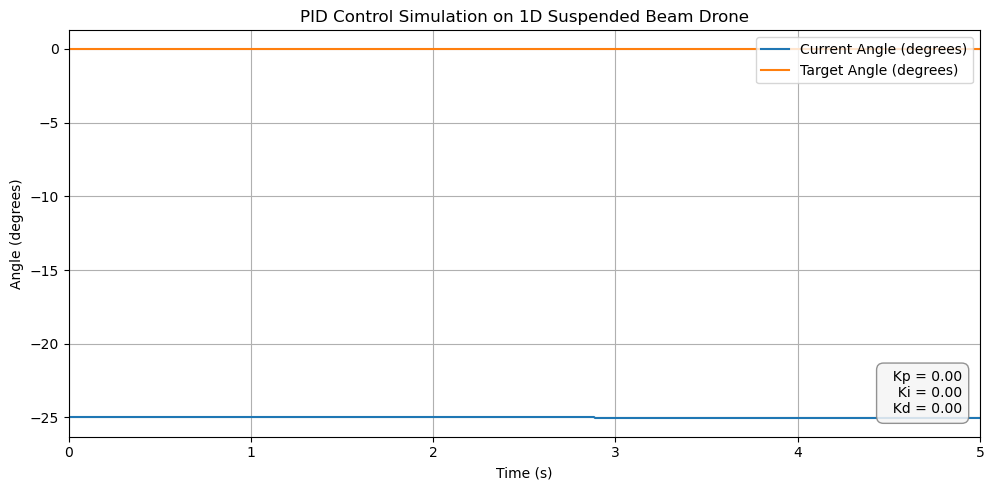

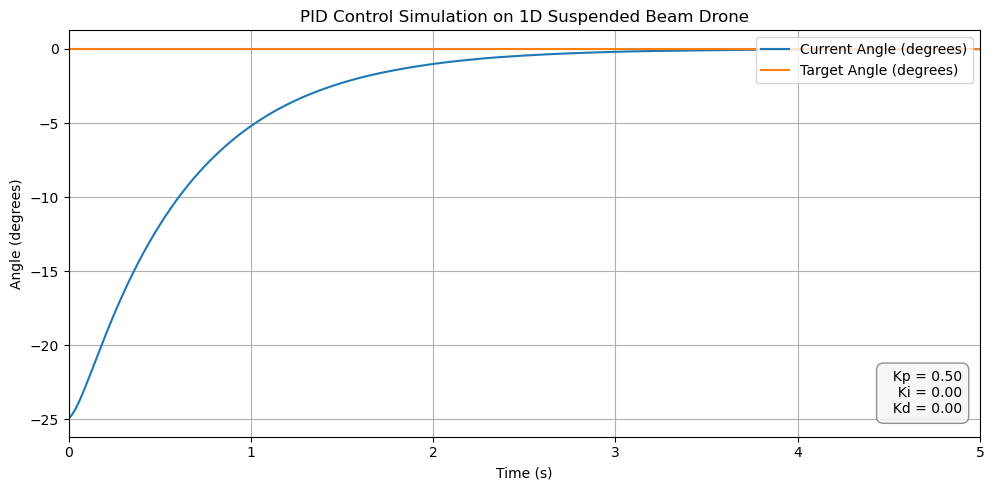

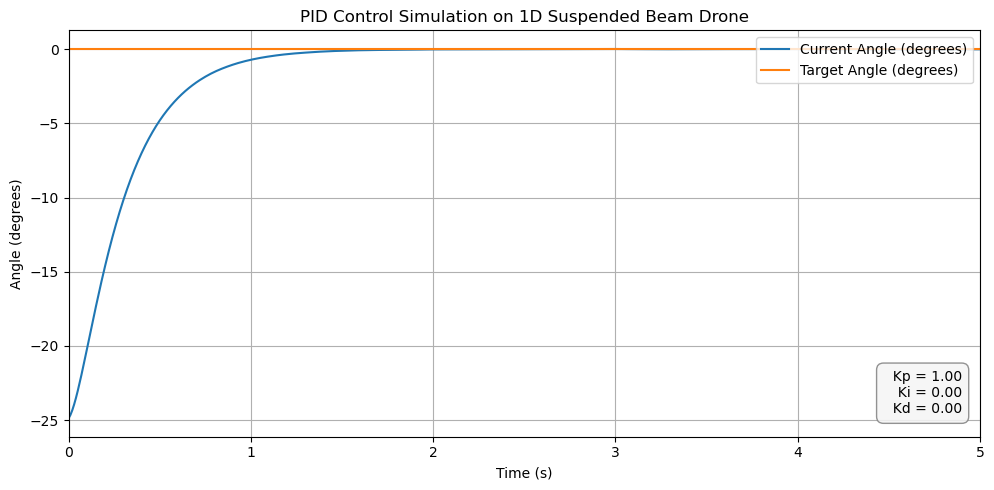

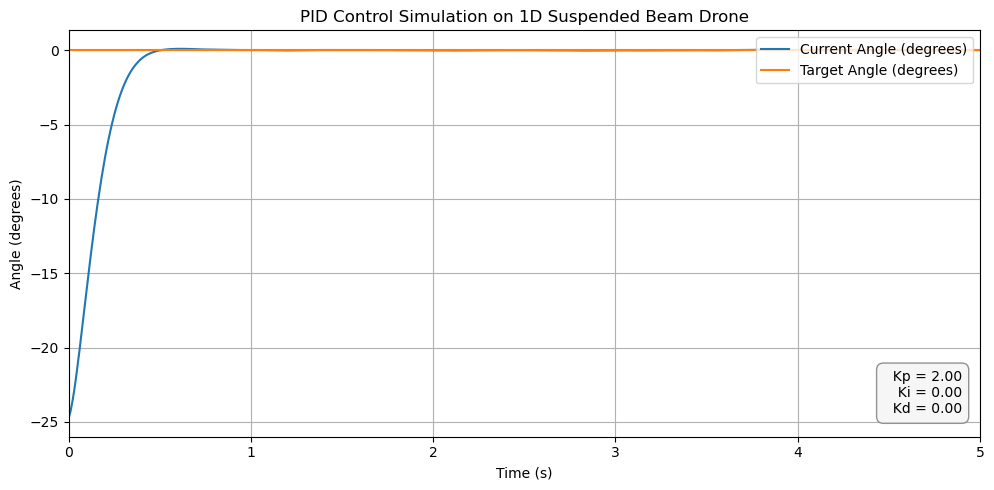

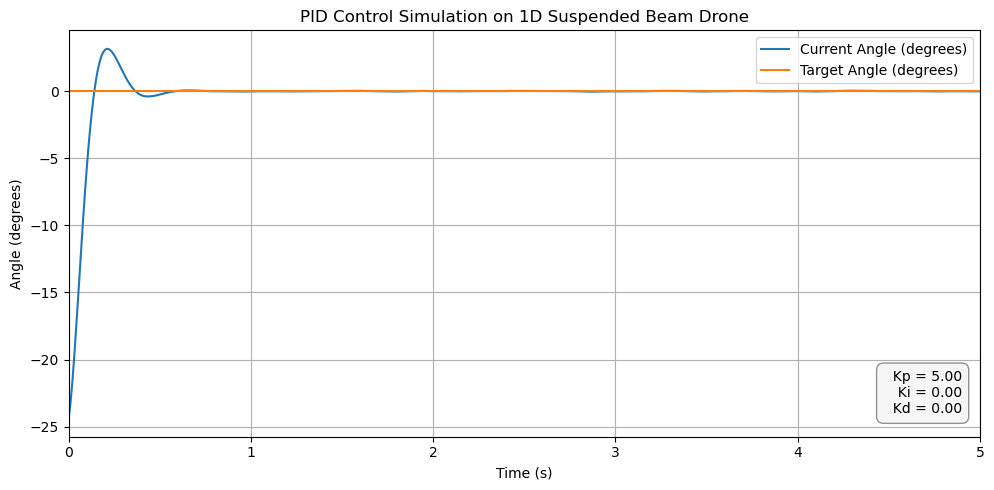

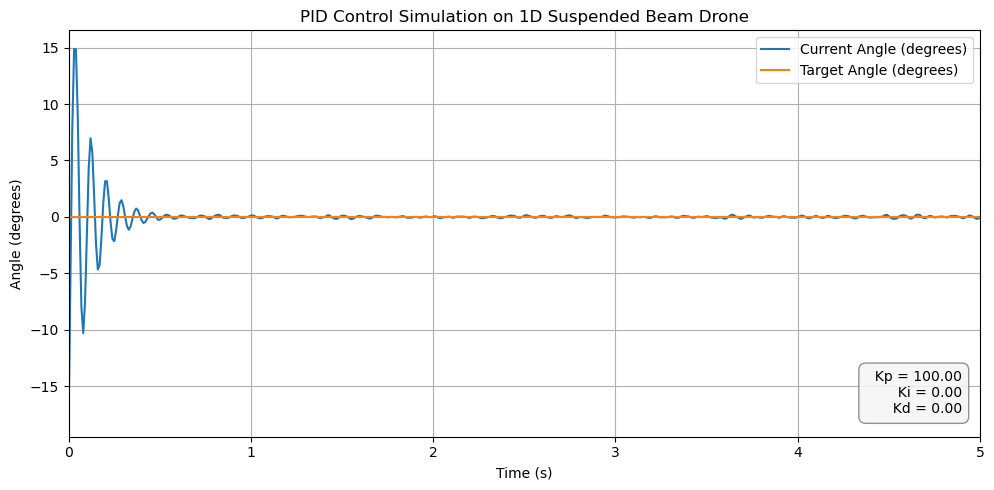

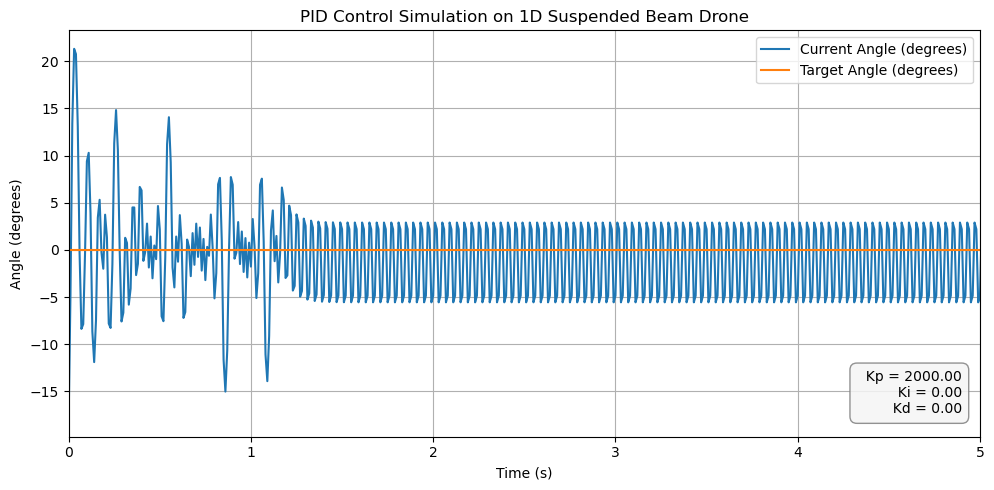

In [60]:
selected_proportional_gains = [0.0, 0.5, 1.0, 2.0, 5.0, 100.0, 2000.0]

for kp in selected_proportional_gains:
    ki = 0.0
    kd = 0.0

    stats_info = (
        f"  Kp = {kp:.2f}\n"
        f"  Ki = {ki:.2f}\n"
        f"  Kd = {kd:.2f}"
    )
    
    target_history = np.full_like(np.array(range(total_steps)), target_angle, dtype=np.float64)
    time_history, angles_history_deg = run_sim(kp=kp, ki=ki, kd=kd)
    plot_results(time_history, target_history, angles_history_deg, "PID Control Simulation on 1D Suspended Beam Drone", text=stats_info)


In [61]:
# I do not know what to do here, seems the system cant achieve margina stability